In [1]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#creating database connection
conn=sqlite3.connect('Inventory.db')

#fetching vendor summary data
df=pd.read_sql_query('select * from purchases',conn)
df.head()

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


#performing EDA again

In [3]:
#summary stats
df.describe().T                        #.T is transpose here column aur row interchange ho jate hai

,count,mean,std,min,25%,50%,75%,max
Store,2372474.0,44.651328,23.512448,1.0,25.00,48.00,67.00,81.00
Brand,2372474.0,12418.641110,12557.278331,58.0,3639.00,6523.00,18877.00,90631.00
VendorNumber,2372474.0,6886.435533,8066.693891,2.0,3252.00,4425.00,9552.00,201359.00
PONumber,2372474.0,11040.936647,1565.340220,8106.0,9761.00,11103.00,12397.00,13661.00
PurchasePrice,2372474.0,12.050050,17.945104,0.0,6.12,9.22,14.49,5681.81
Quantity,2372474.0,14.155846,23.446162,1.0,6.00,10.00,12.00,3816.00
Dollars,2372474.0,135.681472,281.664941,0.0,49.26,83.93,140.52,50175.70
Classification,2372474.0,1.443520,0.496800,1.0,1.00,1.00,2.00,2.00


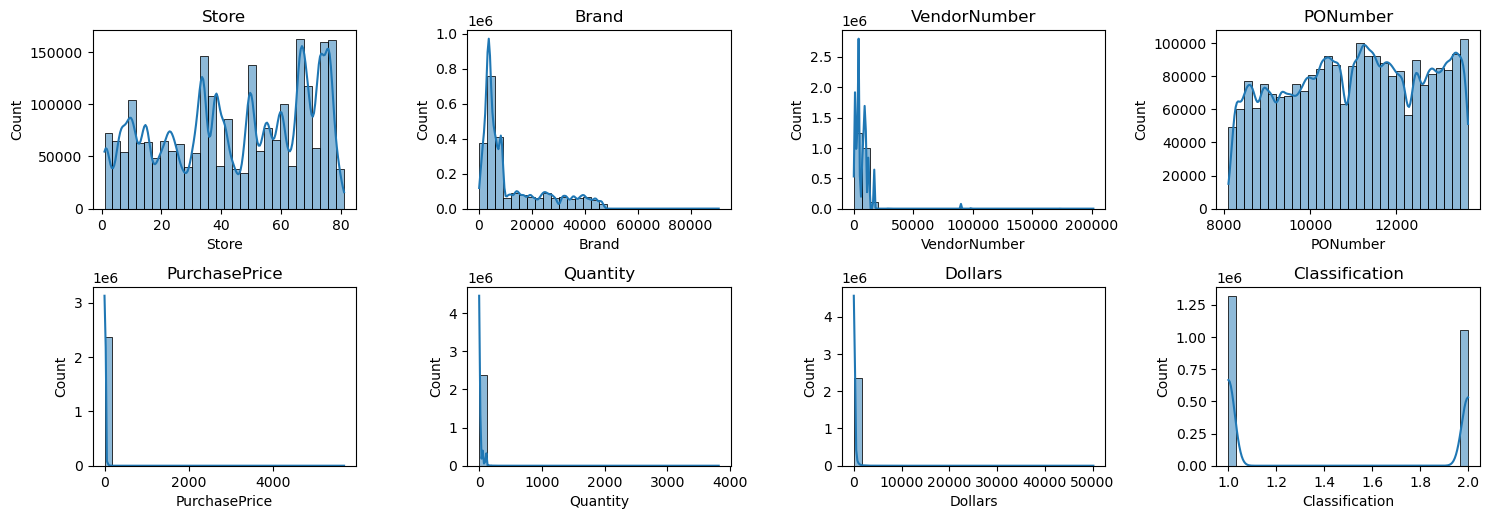

In [4]:
#Distribution Plots for Numerical Columns
numerical_cols=df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()


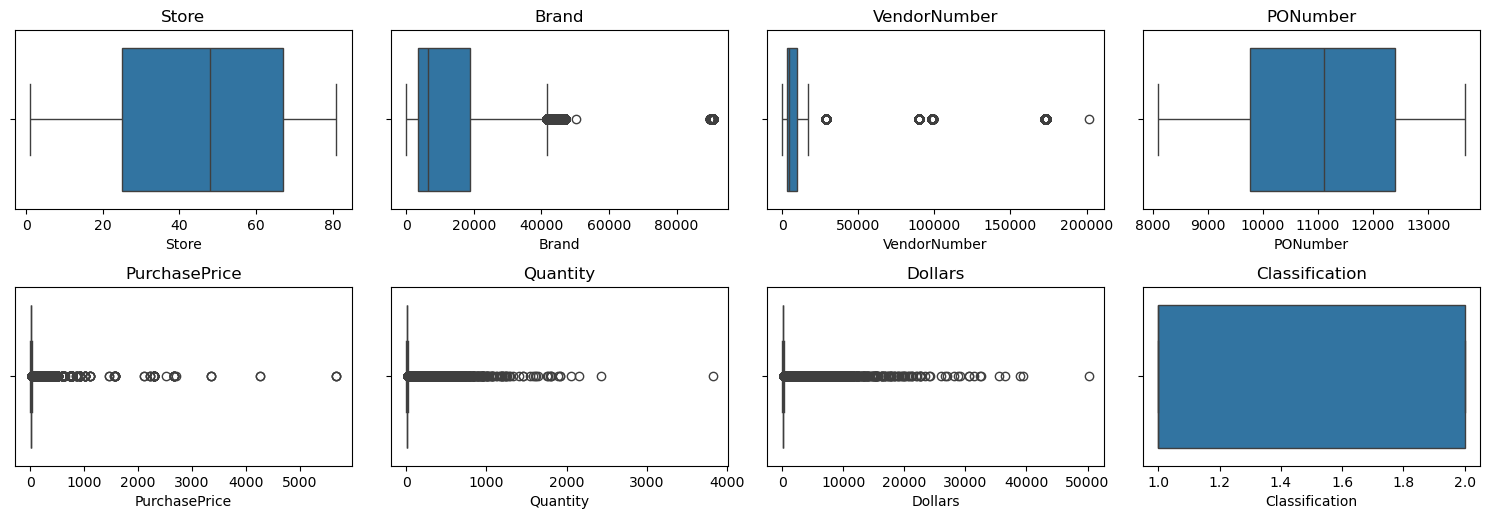

In [5]:
#Distribution Plots for Numerical Columns
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(x=df[col])   # only x or y, no kde/bins
    plt.title(col)
plt.tight_layout()
plt.show()

#negative values and outliers present

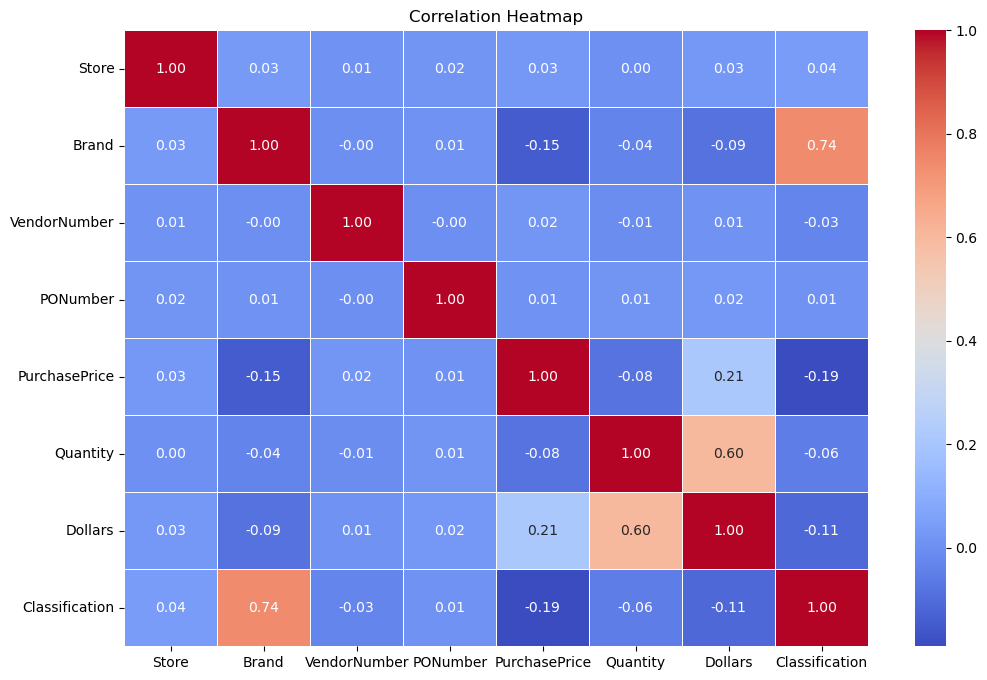

In [7]:
#Co-relation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df [numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [11]:
#filter the data by removing inconsistencies
df=pd.read_sql_query("""SELECT *
FROM purchases
WHERE Quantity>0
AND Size>0 """, conn)
df

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2372466,49_GARIGILL_22298,49,22298,Zorvino Vyds Sangiovese,750mL,90058,ZORVINO VINEYARDS,13593,2024-12-19,2024-12-28,2025-01-09,2025-02-06,8.06,12,96.72,2
2372467,1_HARDERSFIELD_19556,1,19556,Zorvino Bacca Z Blackberry,750mL,90058,ZORVINO VINEYARDS,13593,2024-12-19,2024-12-27,2025-01-09,2025-02-06,9.39,12,112.68,2
2372468,66_EANVERNESS_22297,66,22297,Zorvino Vyds Pearz,750mL,90058,ZORVINO VINEYARDS,13593,2024-12-19,2024-12-26,2025-01-09,2025-02-06,6.75,12,81.00,2
2372469,69_MOUNTMEND_19557,69,19557,Zorvino Fragole Z Strawberry,750mL,90058,ZORVINO VINEYARDS,13593,2024-12-19,2024-12-26,2025-01-09,2025-02-06,9.39,12,112.68,2


#JUDGING OTHER PARAMETERS:

In [21]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Database connection
conn = sqlite3.connect('Inventory.db')

# Load datasets
begin_inventory = pd.read_sql('SELECT * FROM begin_inventory', conn)
end_inventory = pd.read_sql('SELECT * FROM end_inventory', conn)
purchases = pd.read_sql('SELECT * FROM purchases', conn)

# Strip whitespace from column names
begin_inventory.columns = begin_inventory.columns.str.strip()
end_inventory.columns = end_inventory.columns.str.strip()
purchases.columns = purchases.columns.str.strip()




In [39]:
# --- 1. Data Overview ---
for name, df in {'Begin Inventory': begin_inventory, 'End Inventory': end_inventory, 'Purchases': purchases}.items():
    print(f"\n{name}: {df.shape[0]} rows, {df.shape[1]} columns")
    display(df.head())

total_dollars = purchases['Dollars'].sum()
total_quantity = purchases['Quantity'].sum()
avg_turnover = None  # Will calculate after turnover
num_products = purchases['InventoryId'].nunique()
print(f"Total Purchase Value: ${total_dollars:,.2f}")
print(f"Total Purchase Quantity: {total_quantity}")
print(f"Number of Products Purchased: {num_products}")


Begin Inventory: 206529 rows, 9 columns


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01



End Inventory: 224489 rows, 9 columns


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31



Purchases: 2372474 rows, 16 columns


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Total Purchase Value: $321,900,765.53
Total Purchase Quantity: 33584377
Number of Products Purchased: 245907


In [23]:
# --- 2. Missing Values & Data Types ---
for name, df in {'Begin Inventory': begin_inventory, 'End Inventory': end_inventory, 'Purchases': purchases}.items():
    print(f"\n{name}")
    display(df.info())
    display(df.isna().sum())




Begin Inventory
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206529 entries, 0 to 206528
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InventoryId  206529 non-null  object 
 1   Store        206529 non-null  int64  
 2   City         206529 non-null  object 
 3   Brand        206529 non-null  int64  
 4   Description  206529 non-null  object 
 5   Size         206529 non-null  object 
 6   onHand       206529 non-null  int64  
 7   Price        206529 non-null  float64
 8   startDate    206529 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 14.2+ MB


None

InventoryId    0
Store          0
City           0
Brand          0
Description    0
Size           0
onHand         0
Price          0
startDate      0
dtype: int64


End Inventory
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224489 entries, 0 to 224488
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InventoryId  224489 non-null  object 
 1   Store        224489 non-null  int64  
 2   City         223205 non-null  object 
 3   Brand        224489 non-null  int64  
 4   Description  224489 non-null  object 
 5   Size         224489 non-null  object 
 6   onHand       224489 non-null  int64  
 7   Price        224489 non-null  float64
 8   endDate      224489 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 15.4+ MB


None

InventoryId       0
Store             0
City           1284
Brand             0
Description       0
Size              0
onHand            0
Price             0
endDate           0
dtype: int64


Purchases
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2372474 entries, 0 to 2372473
Data columns (total 16 columns):
 #   Column          Dtype  
---  ------          -----  
 0   InventoryId     object 
 1   Store           int64  
 2   Brand           int64  
 3   Description     object 
 4   Size            object 
 5   VendorNumber    int64  
 6   VendorName      object 
 7   PONumber        int64  
 8   PODate          object 
 9   ReceivingDate   object 
 10  InvoiceDate     object 
 11  PayDate         object 
 12  PurchasePrice   float64
 13  Quantity        int64  
 14  Dollars         float64
 15  Classification  int64  
dtypes: float64(2), int64(6), object(8)
memory usage: 289.6+ MB


None

InventoryId       0
Store             0
Brand             0
Description       0
Size              3
VendorNumber      0
VendorName        0
PONumber          0
PODate            0
ReceivingDate     0
InvoiceDate       0
PayDate           0
PurchasePrice     0
Quantity          0
Dollars           0
Classification    0
dtype: int64

In [30]:
# --- 3. Purchase Trends ---
#TOP PURCHSES BY INVENTORY ID WRT DOLLARS
purchase_summary = purchases.groupby('InventoryId')[['Quantity', 'Dollars']].sum().reset_index()
purchase_summary.sort_values('Dollars', ascending=False).head(10)



,InventoryId,Quantity,Dollars
121528,50_MOUNTMEND_1233,9463,248593.01
222396,76_DONCASTER_3405,10124,234775.56
73599,34_PITMERDEN_3405,8115,188186.85
128471,50_MOUNTMEND_8068,10302,187908.48
73743,34_PITMERDEN_3545,8104,177396.56
175295,66_EANVERNESS_3405,7589,175988.91
222522,76_DONCASTER_3545,7637,167173.93
84841,38_GOULCREST_3405,6992,162144.48
74566,34_PITMERDEN_4261,9920,160406.40
208666,73_DONCASTER_3405,6768,156949.92


In [43]:
# --- 4. Inventory vs Purchases (INVENTORY CHANGE FROM BEGINNING TO END)---
# Merge begin and end inventory with purchases to see stock changes
inv = pd.merge(begin_inventory[['InventoryId', 'onHand']], end_inventory[['InventoryId', 'onHand']], 
               on='InventoryId', suffixes=('_begin', '_end'))
inv = pd.merge(inv, purchase_summary, on='InventoryId', how='left')
inv['Quantity'] = inv['Quantity'].fillna(0)
inv['Dollars'] = inv['Dollars'].fillna(0)

# Calculate inventory change
inv['StockChange'] = (inv['onHand_end'] + inv['Quantity']) - inv['onHand_begin']
inv.head(10)

#STOCK CHANGE-HIGH OR LOW
# Sort inventory_change by StockChange descending for high stock
high_stock = inventory_change.sort_values('StockChange', ascending=False).head(10)

# Sort inventory_change by StockChange ascending for low stock
low_stock = inventory_change.sort_values('StockChange', ascending=True).head(10)

high_stock, low_stock


(                InventoryId  onHand_begin  onHand_end  Quantity  StockChange
 166052    76_DONCASTER_6570           621         774   12705.0      12858.0
 107772      53_HILLFAR_8111           448        1066   11648.0      12266.0
 101573    50_MOUNTMEND_8068           601        1273   10302.0      10974.0
 54233     27_MOUNTMEND_8111           291         269   10785.0      10763.0
 38955   20_BREDWARDINE_8111           359           2   10784.0      10427.0
 169618     77_TAMWORTH_5111           313         339   10299.0      10325.0
 139843   67_EANVERNESS_5111           164        3005    7409.0      10250.0
 165344    76_DONCASTER_3405           392         508   10124.0      10240.0
 68651     34_PITMERDEN_6570           550         807    9969.0      10226.0
 100172    50_MOUNTMEND_1233           537        1246    9463.0      10172.0,
                 InventoryId  onHand_begin  onHand_end  Quantity  StockChange
 172665    79_BALLYMENA_3859          1163         351      63.

In [26]:


# --- 5. Inventory Turnover Estimation ---
# Using purchase dollars as proxy for cost
inv['Turnover'] = inv['Dollars'] / ((inv['onHand_begin'] + inv['onHand_end']) / 2)
inv.replace([np.inf, -np.inf], np.nan, inplace=True)
inv.head(10)

# --- 6. Time Trends ---
purchases['PODate'] = pd.to_datetime(purchases['PODate'])
monthly_purchases = purchases.groupby(purchases['PODate'].dt.to_period('M'))['Dollars'].sum()

plt.figure(figsize=(12,6))
monthly_purchases.plot(label='Purchases', legend=True)
plt.title('Monthly Purchases Over Time')
plt.ylabel('Dollars')
plt.show()

,InventoryId,onHand_begin,onHand_end,Quantity,Dollars,StockChange,Turnover
0,1_HARDERSFIELD_58,8,11,105.0,974.40,108.0,102.568421
1,1_HARDERSFIELD_62,6,7,116.0,3325.72,117.0,511.649231
2,1_HARDERSFIELD_63,3,7,59.0,1797.14,63.0,359.428000
3,1_HARDERSFIELD_72,6,4,0.0,0.00,-2.0,0.000000
4,1_HARDERSFIELD_75,18,7,0.0,0.00,-11.0,0.000000
5,1_HARDERSFIELD_77,7,18,132.0,1371.48,143.0,109.718400
6,1_HARDERSFIELD_79,2,7,96.0,923.52,101.0,205.226667
7,1_HARDERSFIELD_115,5,35,150.0,3205.50,180.0,160.275000
8,1_HARDERSFIELD_126,17,36,530.0,10674.20,549.0,402.800000
9,1_HARDERSFIELD_171,12,24,96.0,3528.96,108.0,196.053333


In [36]:
# Sort inventory_change by StockChange ascending for low stock
low_stock = inventory_change.sort_values('StockChange', ascending=True).head(10)

high_stock, low_stock

(                InventoryId  onHand_begin  onHand_end  Quantity  StockChange
 166052    76_DONCASTER_6570           621         774   12705.0      12858.0
 107772      53_HILLFAR_8111           448        1066   11648.0      12266.0
 101573    50_MOUNTMEND_8068           601        1273   10302.0      10974.0
 54233     27_MOUNTMEND_8111           291         269   10785.0      10763.0
 38955   20_BREDWARDINE_8111           359           2   10784.0      10427.0
 169618     77_TAMWORTH_5111           313         339   10299.0      10325.0
 139843   67_EANVERNESS_5111           164        3005    7409.0      10250.0
 165344    76_DONCASTER_3405           392         508   10124.0      10240.0
 68651     34_PITMERDEN_6570           550         807    9969.0      10226.0
 100172    50_MOUNTMEND_1233           537        1246    9463.0      10172.0,
                 InventoryId  onHand_begin  onHand_end  Quantity  StockChange
 172665    79_BALLYMENA_3859          1163         351      63.

#inventory turnover
##turnover=sales/(begin inventory-end inventory)/2

#VISULAIZATIONS

In [38]:
# --- 6. Time Trends ---
purchases['PODate'] = pd.to_datetime(purchases['PODate'])
monthly_purchases = purchases.groupby(purchases['PODate'].dt.to_period('M'))['Dollars'].sum()

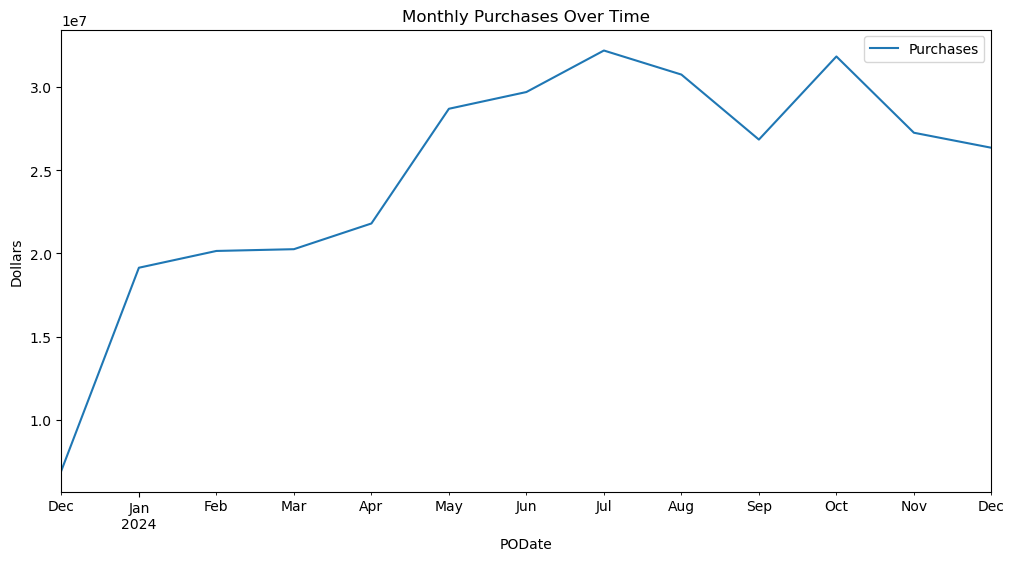

In [28]:
plt.figure(figsize=(12,6))
monthly_purchases.plot(label='Purchases', legend=True)
plt.title('Monthly Purchases Over Time')
plt.ylabel('Dollars')
plt.show()

In [47]:
#KPI Cards (Summary Metrics)
total_dollars = purchases['Dollars'].sum()
total_quantity = purchases['Quantity'].sum()
avg_turnover = inventory_turnover['Turnover'].mean()
num_products = purchases['InventoryId'].nunique()

print(f"Total Purchase Value: ${total_dollars:,.2f}")
print(f"Total Purchase Quantity: {total_quantity}")
print(f"Average Inventory Turnover: {avg_turnover:.2f}")
print(f"Number of Products Purchased: {num_products}")


Total Purchase Value: $321,900,765.53
Total Purchase Quantity: 33584377
Average Inventory Turnover: 88.96
Number of Products Purchased: 245907


C:\Users\Ananta\AppData\Local\Temp\ipykernel_16928\3999848300.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_value.index, y=top_value.values, palette="viridis")


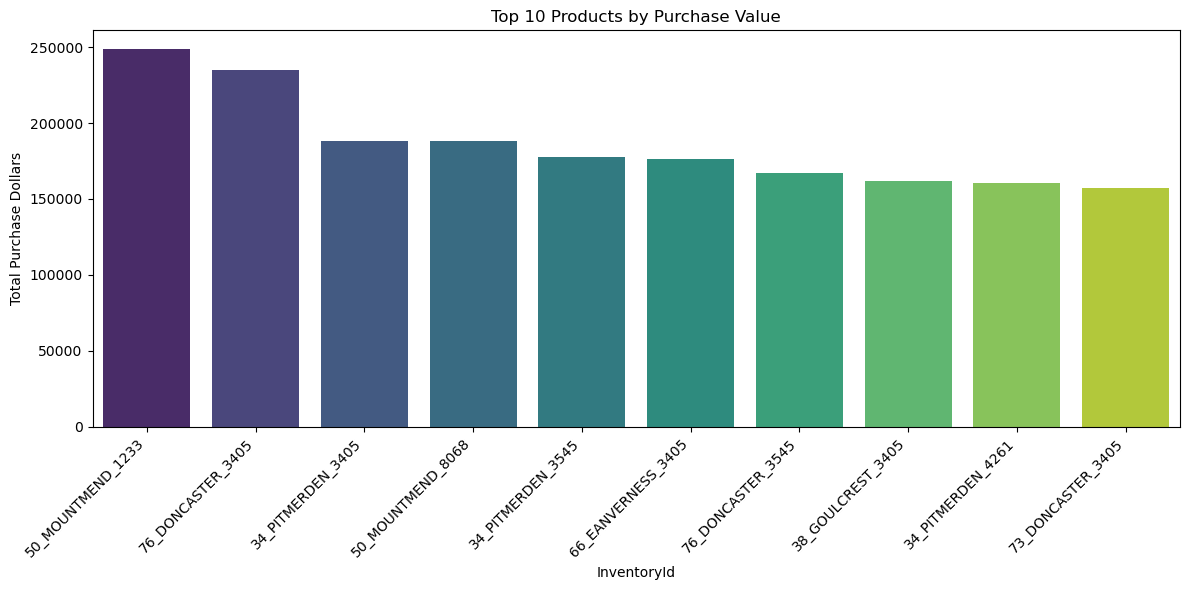

In [48]:
#TOP PRODUCTS BY PURCHASE VALUE:
top_value = purchases.groupby('InventoryId')['Dollars'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_value.index, y=top_value.values, palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Products by Purchase Value')
plt.ylabel('Total Purchase Dollars')
plt.xlabel('InventoryId')
plt.tight_layout()
plt.show()


C:\Users\Ananta\AppData\Local\Temp\ipykernel_16928\4209303468.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_quantity.index, y=top_quantity.values, palette="magma")


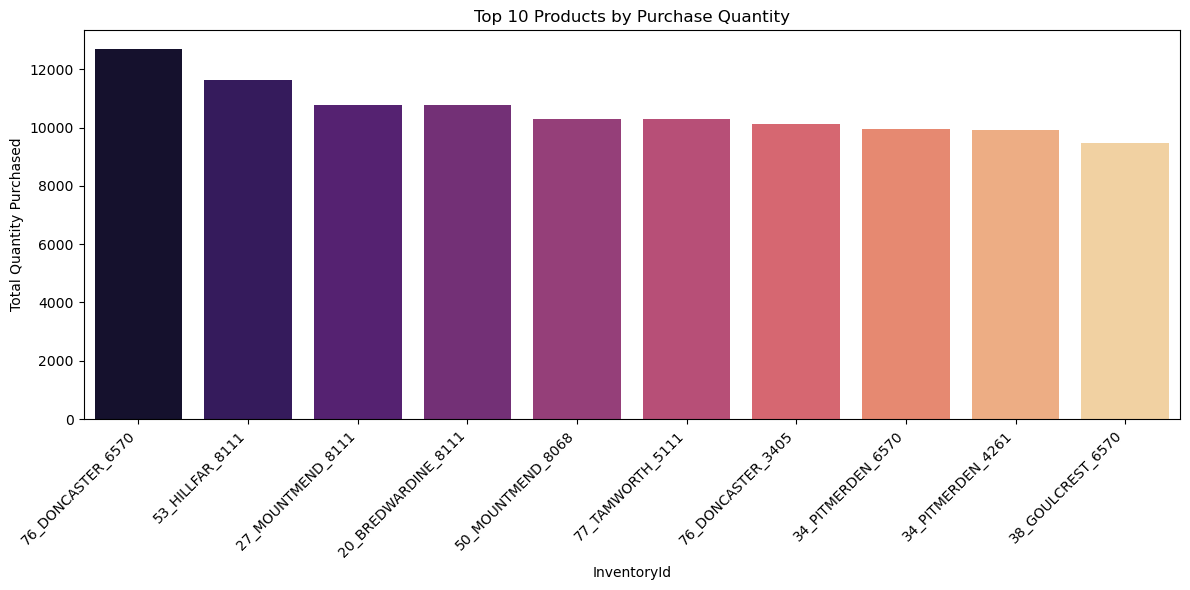

In [49]:
#TOP PRODUCTS BY QUANTITY
top_quantity = purchases.groupby('InventoryId')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_quantity.index, y=top_quantity.values, palette="magma")
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Products by Purchase Quantity')
plt.ylabel('Total Quantity Purchased')
plt.xlabel('InventoryId')
plt.tight_layout()
plt.show()


In [50]:
#STOCK CHANGE TABLE
# Already calculated as inventory_change['StockChange']
# Highlight positive (green) and negative (red)
inventory_change_sorted = inventory_change.sort_values('StockChange', ascending=False).head(10)
print(inventory_change_sorted[['InventoryId','onHand_begin','Quantity','onHand_end','StockChange']])


                InventoryId  onHand_begin  Quantity  onHand_end  StockChange
166052    76_DONCASTER_6570           621   12705.0         774      12858.0
107772      53_HILLFAR_8111           448   11648.0        1066      12266.0
101573    50_MOUNTMEND_8068           601   10302.0        1273      10974.0
54233     27_MOUNTMEND_8111           291   10785.0         269      10763.0
38955   20_BREDWARDINE_8111           359   10784.0           2      10427.0
169618     77_TAMWORTH_5111           313   10299.0         339      10325.0
139843   67_EANVERNESS_5111           164    7409.0        3005      10250.0
165344    76_DONCASTER_3405           392   10124.0         508      10240.0
68651     34_PITMERDEN_6570           550    9969.0         807      10226.0
100172    50_MOUNTMEND_1233           537    9463.0        1246      10172.0


C:\Users\Ananta\AppData\Local\Temp\ipykernel_16928\1378231715.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=turnover_sorted['InventoryId'], y=turnover_sorted['Turnover'], palette="coolwarm")


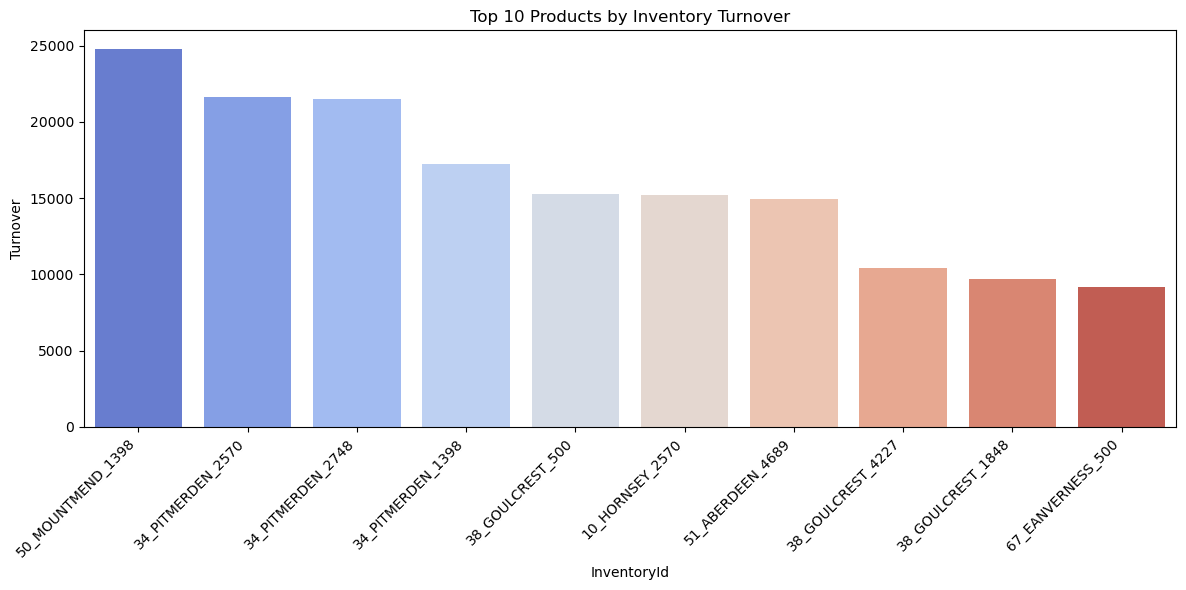

In [52]:
#INVENTORY TURNOVER BAR CHART:
turnover_sorted = inventory_turnover.sort_values('Turnover', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=turnover_sorted['InventoryId'], y=turnover_sorted['Turnover'], palette="coolwarm")
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Products by Inventory Turnover')
plt.ylabel('Turnover')
plt.xlabel('InventoryId')
plt.tight_layout()
plt.show()


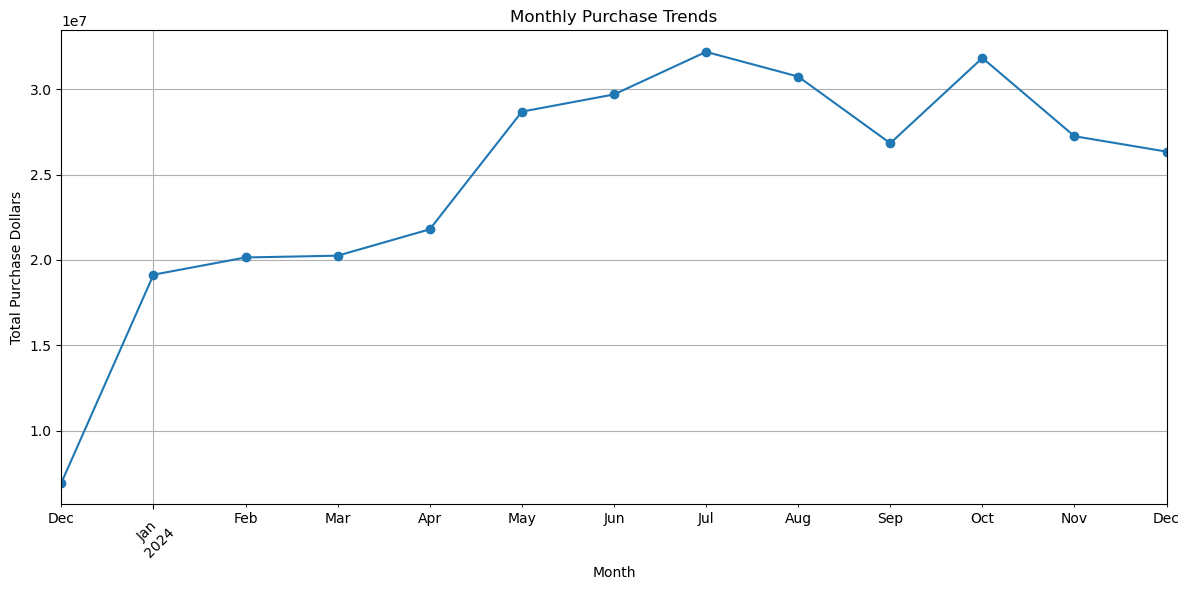

In [53]:
#PIURCHASE TRENDS OVER TIME:
purchases['PODate'] = pd.to_datetime(purchases['PODate'])
monthly_purchases = purchases.groupby(purchases['PODate'].dt.to_period('M'))['Dollars'].sum()

plt.figure(figsize=(12,6))
monthly_purchases.plot(marker='o')
plt.title('Monthly Purchase Trends')
plt.xlabel('Month')
plt.ylabel('Total Purchase Dollars')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\Ananta\AppData\Local\Temp\ipykernel_16928\3941092285.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vendors.index, y=top_vendors.values, palette="plasma")


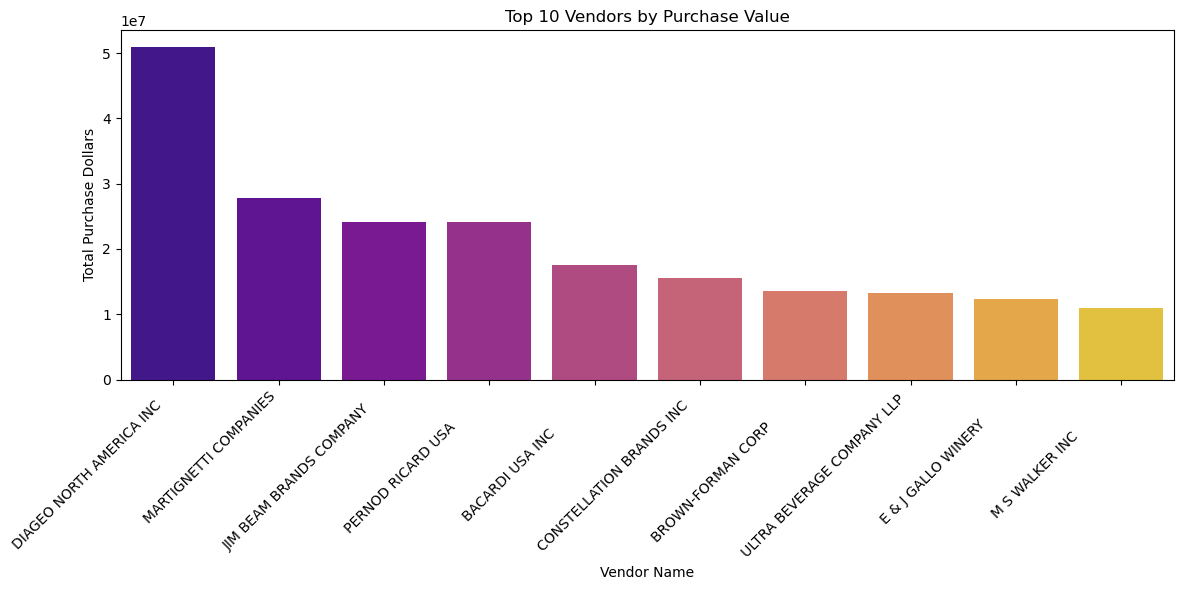

In [54]:
#ANALYSIS:
top_vendors = purchases.groupby('VendorName')['Dollars'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_vendors.index, y=top_vendors.values, palette="plasma")
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Vendors by Purchase Value')
plt.ylabel('Total Purchase Dollars')
plt.xlabel('Vendor Name')
plt.tight_layout()
plt.show()


C:\Users\Ananta\AppData\Local\Temp\ipykernel_16928\689451405.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.index, y=top_brands.values, palette="Set2")


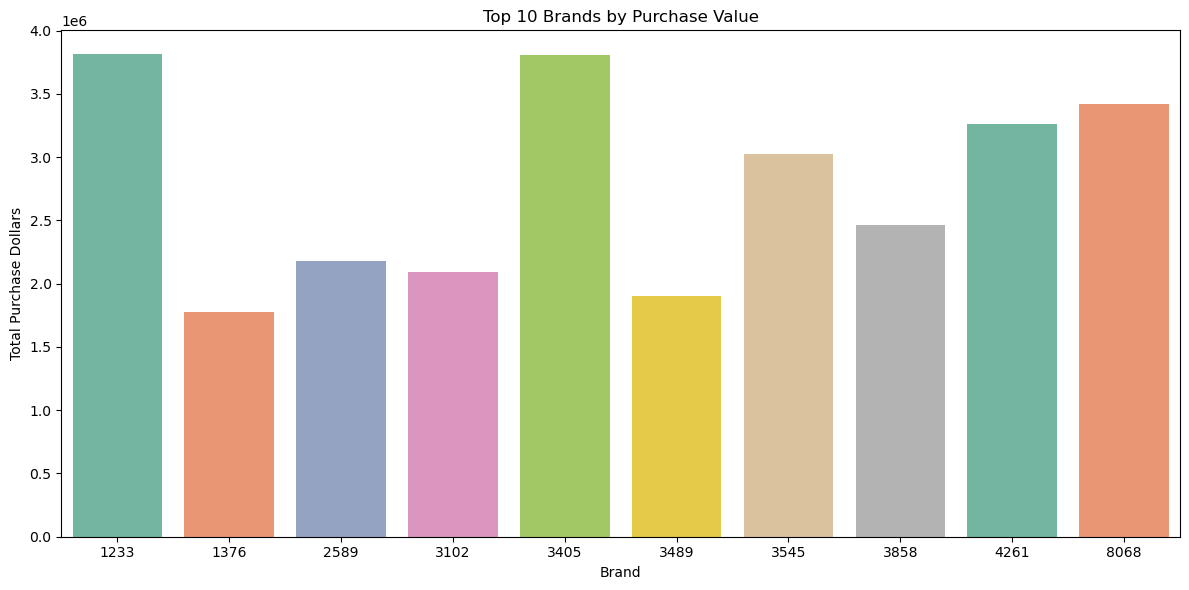

In [55]:
#CLASSIFICATION ANALYSIS:
top_brands = purchases.groupby('Brand')['Dollars'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_brands.index, y=top_brands.values, palette="Set2")
plt.title('Top 10 Brands by Purchase Value')
plt.xlabel('Brand')
plt.ylabel('Total Purchase Dollars')
plt.tight_layout()
plt.show()

